# Simulation CSV Plots

Set `CSV_PATH` below if you want a specific run. Leave it as `None` to use the newest `data/run_*.csv` file.

In [2]:
# Uncomment this if your notebook kernel does not have the plotting packages:
# %pip install pandas matplotlib

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "misc":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Set this to a specific file if needed, for example:
# CSV_PATH = PROJECT_ROOT / "data" / "run_2026-06-07T19-54-22.csv"
CSV_PATH = None

if CSV_PATH is None:
    run_files = sorted((PROJECT_ROOT / "data").glob("run_*.csv"), key=lambda path: path.stat().st_mtime)
    if not run_files:
        raise FileNotFoundError("No data/run_*.csv files found")
    CSV_PATH = run_files[-1]

df = pd.read_csv(CSV_PATH)
df.head()

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 6.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 3.8 MB/s eta 0:00:00a 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 4.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 4.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 4.1 MB/s eta 0:00:00a 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
Note: you may need to restart the kernel to use updated packages.


,epoch,population,food,bushes,avg_speed,avg_vision,avg_reproduction,max_generation,oldest_age,births,deaths,food_eaten
0,1,20,9,15,100.00,150.00,200.00,0,1.0,0,0,6
1,2,22,1,15,99.88,151.05,198.78,1,2.0,2,0,8
2,3,22,4,15,99.88,151.05,198.78,1,3.0,0,0,1
3,4,23,9,15,100.29,151.74,198.96,1,4.0,1,0,3
4,5,24,4,15,100.49,152.12,199.30,1,5.0,1,0,8


In [3]:
print(f"Loaded: {CSV_PATH}")
print(f"Rows: {len(df)}")
df.describe().T

Loaded: /Users/naresh/evolution/data/run_2026-06-07T19-54-22.csv
Rows: 515


,count,mean,std,min,25%,50%,75%,max
epoch,515.0,258.000000,148.811962,1.00,129.500,258.00,386.500,515.00
population,515.0,37.805825,58.122181,18.00,23.000,24.00,26.000,472.00
food,515.0,3.970874,2.825180,0.00,2.000,4.00,5.000,16.00
bushes,515.0,15.000000,0.000000,15.00,15.000,15.00,15.000,15.00
avg_speed,515.0,149.106369,50.165575,99.88,116.020,135.63,162.230,394.28
avg_vision,515.0,188.041534,22.449318,77.24,177.440,194.29,204.630,255.25
avg_reproduction,515.0,196.097922,38.114492,66.96,196.505,209.78,220.225,233.82
max_generation,515.0,27.469903,66.833964,0.00,6.000,10.00,20.000,459.00
oldest_age,515.0,113.210350,54.522171,1.00,74.595,120.52,156.830,219.67
births,515.0,7.260194,31.630993,0.00,0.000,1.00,1.000,341.00


In [4]:
def plot_columns(title, columns, normalize=False):
    missing = [column for column in columns if column not in df.columns]
    if missing:
        raise KeyError(f"Missing columns: {missing}")

    plot_df = df[["epoch", *columns]].copy()

    if normalize:
        for column in columns:
            min_value = plot_df[column].min()
            max_value = plot_df[column].max()
            if max_value != min_value:
                plot_df[column] = (plot_df[column] - min_value) / (max_value - min_value)

    fig, ax = plt.subplots(figsize=(12, 5.5))

    for column in columns:
        ax.plot(plot_df["epoch"], plot_df[column], linewidth=2, label=column)

    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.set_ylabel("normalized value" if normalize else "value")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    plt.show()

## Plot 1: Population Dynamics

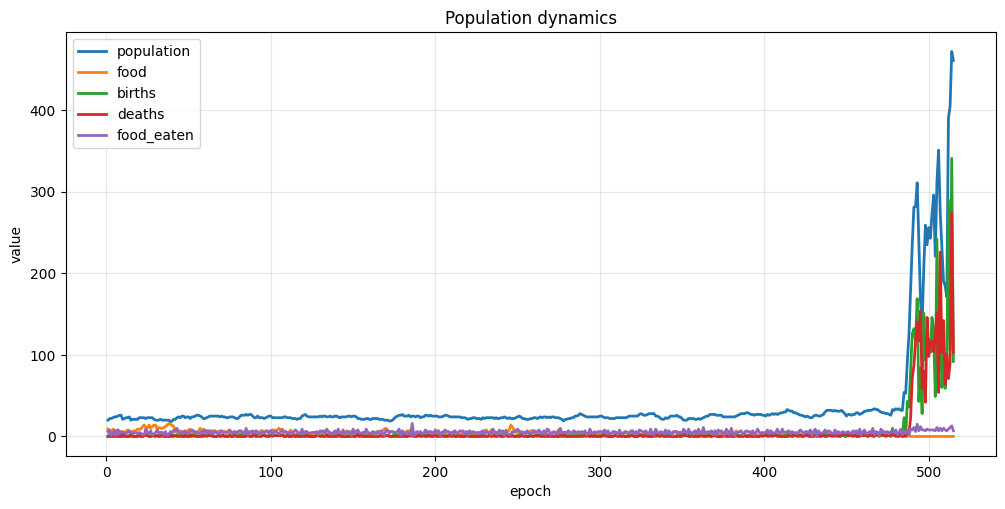

In [5]:
plot_columns(
    "Population dynamics",
    ["population", "food", "births", "deaths", "food_eaten"],
    normalize=False,
)

## Plot 2: Average Traits

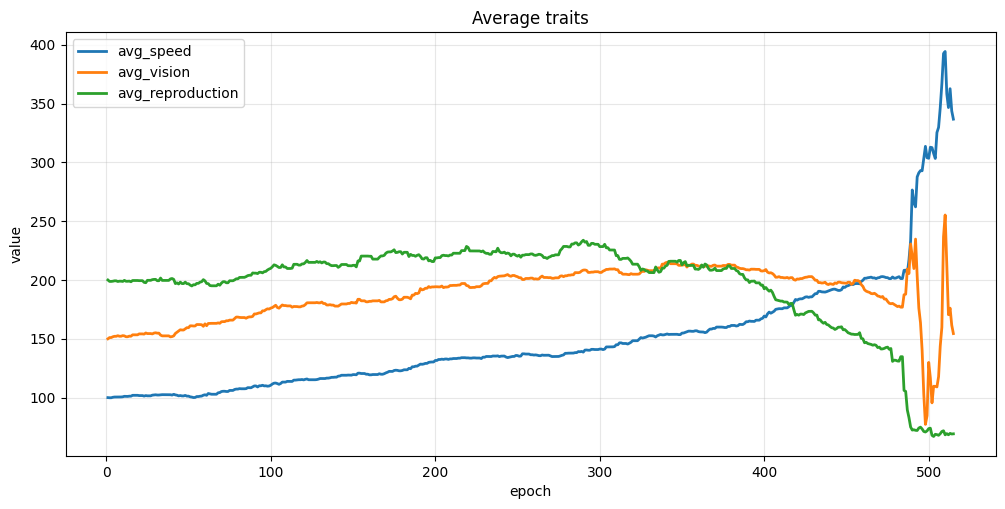

In [6]:
plot_columns(
    "Average traits",
    ["avg_speed", "avg_vision", "avg_reproduction"],
    normalize=False,
)

## Plot 3: Age And Generation

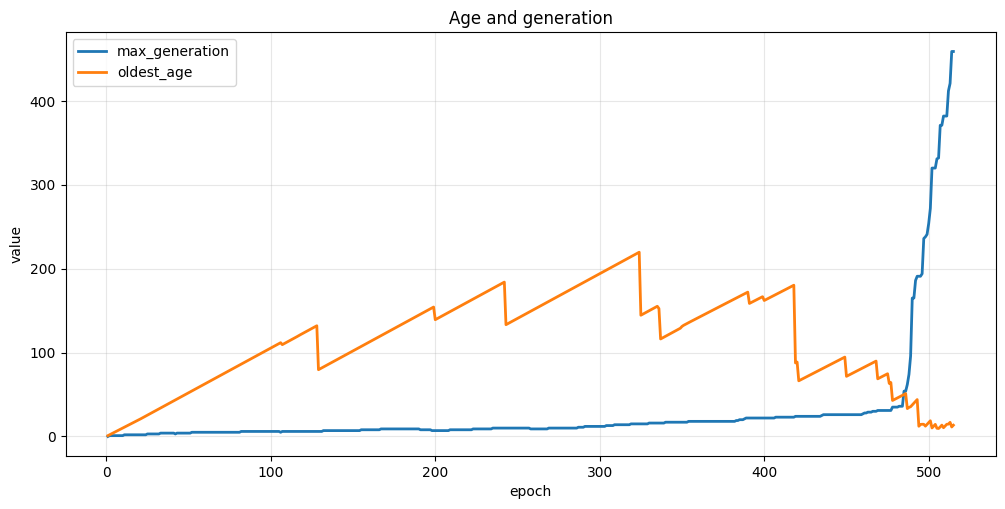

In [7]:
plot_columns(
    "Age and generation",
    ["max_generation", "oldest_age"],
    normalize=False,
)